# LAB exam assignment 1


# Task A: Data Audit & Quality

## Data Dictionary

Quick reference for all columns in `marketing_campaign.csv`. 
Types reflect actual dtypes in the loaded DataFrame.

---

## `marketing_campaign.csv` — Customer Profile

| Column | Type | Description |
|---|---|---|
| `ID` | integer | Unique identifier for each customer |
| `Year_Birth` | integer | Customer's birth year |
| `Education` | string | Customer's education level (`Basic`, `2n Cycle`, `Graduation`, `Master`, `PhD`) |
| `Marital_Status` | string | Customer's marital status (`Single`, `Married`, `Together`, `Divorced`, `Widow`) |
| `Income` | float | Customer's yearly household income in - I suppose - dollars |
| `Kidhome` | integer | Number of small children in the customer's household |
| `Teenhome` | integer | Number of teenagers in the customer's household |
| `Dt_Customer` | string (date) | Date of customer's enrollment with the company |
| `Recency` | integer | Number of days since the customer's last purchase |

---

## `marketing_campaign.csv` — Spending Behaviour

| Column | Type | Description |
|---|---|---|
| `MntWines` | integer | Amount spent on wine in the last 2 years ($) |
| `MntFruits` | integer | Amount spent on fruits in the last 2 years ($) |
| `MntMeatProducts` | integer | Amount spent on meat in the last 2 years ($) |
| `MntFishProducts` | integer | Amount spent on fish in the last 2 years ($) |
| `MntSweetProducts` | integer | Amount spent on sweets in the last 2 years ($) |
| `MntGoldProds` | integer | Amount spent on gold products in the last 2 years ($) |

---

## `marketing_campaign.csv` — Purchase Channels

| Column | Type | Description |
|---|---|---|
| `NumDealsPurchases` | integer | Number of purchases made with a discount |
| `NumWebPurchases` | integer | Number of purchases made through the company's website |
| `NumCatalogPurchases` | integer | Number of purchases made using a catalogue |
| `NumStorePurchases` | integer | Number of purchases made directly in stores |
| `NumWebVisitsMonth` | integer | Number of visits to the company's website in the last month |

---

## `marketing_campaign.csv` — Campaign Responses

| Column | Type | Description |
|---|---|---|
| `AcceptedCmp1` | integer | `1` if customer accepted the offer in the 1st campaign, `0` otherwise |
| `AcceptedCmp2` | integer | `1` if customer accepted the offer in the 2nd campaign, `0` otherwise |
| `AcceptedCmp3` | integer | `1` if customer accepted the offer in the 3rd campaign, `0` otherwise |
| `AcceptedCmp4` | integer | `1` if customer accepted the offer in the 4th campaign, `0` otherwise |
| `AcceptedCmp5` | integer | `1` if customer accepted the offer in the 5th campaign, `0` otherwise |
| `Complain` | integer | `1` if customer complained in the last 2 years, `0` otherwise |
| `Response` | integer | `1` if customer accepted the offer in the **last** campaign, `0` otherwise |

## Setup
Importing required libraries and loading `marketing_campaign.csv` 
(separator: `;`, shape: 2,240 rows × 27 columns).

### Import libraries and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep=';')

print("Marketing Data shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Marketing Data shape: (2240, 27)

Column names:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


### Structural Overview
Variable types, missing values, and duplicate records.

In [4]:
print("--- Marketing Campaign Dataset Info ---")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

--- Marketing Campaign Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15

### Categorical Columns — Value Validation

In [5]:
cat_cols = ['Education', 'Marital_Status']

for col in cat_cols:
    display(
        df[col].value_counts()
        .rename_axis(col)
        .reset_index(name='Count')
        .style.set_caption(f"{col} — Value Counts")
        .set_table_styles([{'selector': 'caption', 
                            'props': [('font-weight', 'bold'), 
                                      ('font-size', '14px')]}])
        .bar(subset=['Count'], color='#4c8cbf', vmin=0)
    )

,Education,Count
0,Graduation,1127
1,PhD,486
2,Master,370
3,2n Cycle,203
4,Basic,54


,Marital_Status,Count
0,Married,864
1,Together,580
2,Single,480
3,Divorced,232
4,Widow,77
5,Alone,3
6,Absurd,2
7,YOLO,2


In [6]:
df[['Income']].describe().T.map(lambda x: f"{x:,.0f}") \
    .style.set_caption("Income — Descriptive Statistics") \
    .set_table_styles([{'selector': 'caption', 
                        'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

,count,mean,std,min,25%,50%,75%,max
Income,"2,216","52,247","25,173","1,730","35,303","51,382","68,522","666,666"


In [7]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df[spend_cols].describe().T.map(lambda x: f"{x:,.0f}") \
    .style.set_caption("Spending Behaviour — Descriptive Statistics") \
    .set_table_styles([{'selector': 'caption', 
                        'props': [('font-weight', 'bold'), ('font-size', '14px')]}])

,count,mean,std,min,25%,50%,75%,max
MntWines,"2,240",304,337,0,24,174,504,"1,493"
MntFruits,"2,240",26,40,0,1,8,33,199
MntMeatProducts,"2,240",167,226,0,16,67,232,"1,725"
MntFishProducts,"2,240",38,55,0,3,12,50,259
MntSweetProducts,"2,240",27,41,0,1,8,33,263
MntGoldProds,"2,240",44,52,0,9,24,56,362


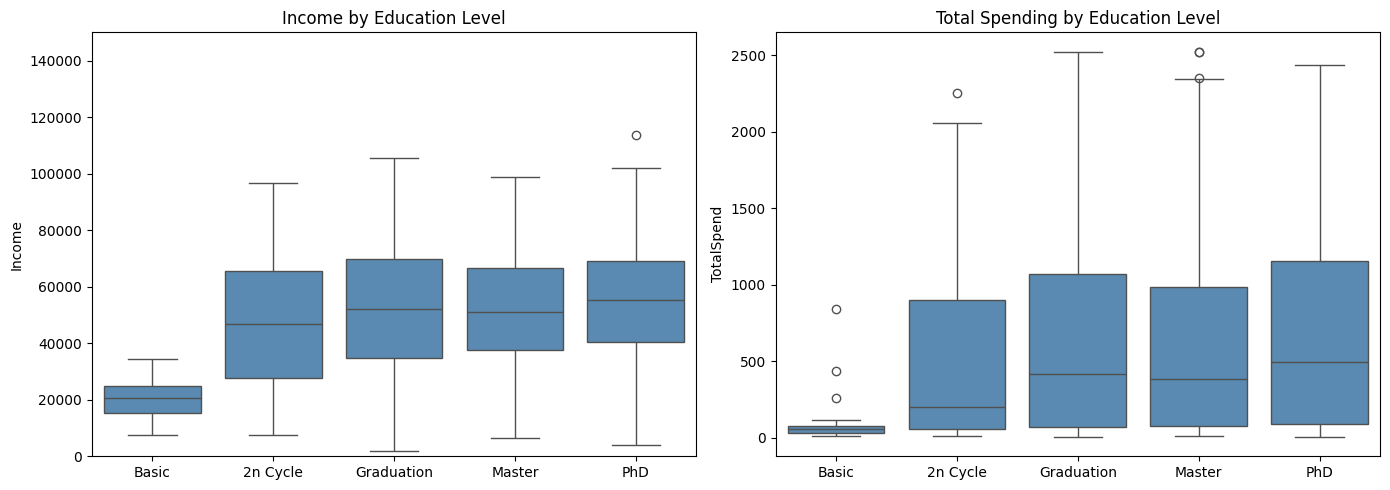

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define order and derived column here so cell is self-contained
edu_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']

df['TotalSpend'] = df[['MntWines', 'MntFruits', 'MntMeatProducts',
                        'MntFishProducts', 'MntSweetProducts', 
                        'MntGoldProds']].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Education', y='Income', 
            order=edu_order, ax=axes[0], color='#4c8cbf')
axes[0].set_ylim(0, 150000)
axes[0].set_title('Income by Education Level')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='Education', y='TotalSpend', 
            order=edu_order, ax=axes[1], color='#4c8cbf')
axes[1].set_title('Total Spending by Education Level')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [10]:
# Numerical summary to support grouping decision
summary = df.groupby('Education')[['Income', 'TotalSpend']].agg(['median', 'mean']) \
            .reindex(edu_order)

summary.columns = ['Income Median', 'Income Mean', 'Spend Median', 'Spend Mean']

display(
    summary.style
    .format({'Income Median': '€{:,.0f}', 'Income Mean': '€{:,.0f}',
             'Spend Median':  '€{:,.0f}', 'Spend Mean':  '€{:,.0f}'})
    .set_caption("Income & Spending by Education Level")
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-weight', 'bold'), ('font-size', '14px')]}])
    .bar(subset=['Income Median', 'Spend Median'], color='#4c8cbf', vmin=0)
)

,Income Median,Income Mean,Spend Median,Spend Mean
Education,,,,
Basic,"€20,744","€20,306",€57,€82
2n Cycle,"€46,805","€47,633",€198,€497
Graduation,"€52,028","€52,720",€414,€620
Master,"€50,943","€52,918",€388,€612
PhD,"€55,212","€56,145",€493,€672


### 1.3 Audit Findings Summary

**Marketing Campaign Dataset:**

- `Income` is the only column with missing values: exactly 24 null entries (~1.07% of the data)

- `Dt_Customer` is stored as `object` (string). It refers to the date on which the customer was enrolled in the database and therefore needs to be converted to `datetime` to be usable for time-based analysis

- `Education` and `Marital_Status` are stored as `object` (string), which is the correct type, but inspection reveals **invalid category values** in `Marital_Status`: `'Absurd'`, `'YOLO'` (2 entries each) and `'Alone'` (3 entries, likely a duplicate of `'Single'`) that need to be handled

- `'2n Cycle'` in `Education` (likely a typo for `'2nd Cycle'`) presented an interpretive 
  ambiguity to me: under the Bologna Process framework, the 2nd cycle corresponds to Master's 
  level, which would suggest merging it with `'Master'`. However, rather than relying on 
  assumptions, I verified this empirically by comparing median income and spending across 
  education levels. The results show that `'2n Cycle'` customers have a median income of 
  €46,805 and a median total spend of €198 — both substantially below `'Graduation'` 
  (€52,028 / €414) and `'Master'` (€50,943 / €388). This places `'2n Cycle'` closer to 
  a sub-bachelor level, so I decided **not** to merge it with `'Master'` and to retain 
  it as a distinct category below `'Graduation'`.



- `Income` carries no currency label either in the raw data or in the assignment 
  description, which simply states "Customer's yearly household income". To investigate 
  the likely unit, I examined the descriptive statistics: the median is 51,382 and the 
  mean is 52,247. Comparing these with national median household incomes around 2012 — 
  the period reflected in the enrollment dates — European countries fall well below this 
  range (e.g. France ~€36,000, Germany ~€33,400, Spain ~€23,700). The US median household 
  income in 2012 was approximately $51,000, which aligns almost exactly with this dataset's 
  median. This suggests values are more likely denominated in **USD**. However, since the 
  currency cannot be confirmed from the data alone, I will treat the unit as a generic 
  monetary value throughout the analysis without assuming a specific currency symbol.

- All spending and purchase columns are correctly typed as `int64`

- No duplicate rows were detected

## Addressing Missing Values and Outliers

First, let's cast incorrect data types to see if structural errors turn into missing values.
We start from `Dt_Customer` since we know it should be a date but is stored as object.
We first inspect the raw values to identify the format, then convert accordingly.

In [ ]:
print(df['Dt_Customer'].head(5))

0    2012-09-04
1    2014-03-08
2    2013-08-21
3    2014-02-10
4    2014-01-19
Name: Dt_Customer, dtype: object


Output confirms format is YYYY-MM-DD , so we use format='%Y-%m-%d'

### Deriving Customer Age from `Dt_Customer`

The `Dt_Customer` column records the date on which each customer was enrolled in the company. Rather than keeping this as a raw date, it is more analytically useful to derive the **age of the customer** at the time they were active in the dataset — since age is a meaningful socio-demographic feature for segmentation and spending analysis.

To compute age, we need a reference date to subtract from `Year_Birth`. Two approaches are defensible here. The first would be to use today's date, which is simple but problematic: it would make customers appear significantly older than they actually were when they were making their purchasing decisions, distorting any analysis that links age to spending behaviour. The second — and the one we adopt here — is to use the **most recent enrollment date present in the dataset** as a proxy for the data collection cutoff. This anchors Age to the period the data actually covers, and has the advantage of being derived directly from the data itself rather than relying on an external, arbitrary date.

In our case, the most recent enrollment date is **June 2014**, so we use **2014 as the reference year**.

In [ ]:
# Convert to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%Y-%m-%d')

# We don't know the exact data collection date.
# We use the most recent record in the dataset as a reference point,
# so that Age reflects how old customers were during the period the data covers.
reference_year = df['Dt_Customer'].dt.year.max()
print("Reference year used:", reference_year)


Reference year used: 2014


In [ ]:
# Compute Age relative to that reference year
df['Age'] = reference_year - df['Year_Birth']

# Verify the conversion worked — check dtype, not missing values
print("Dt_Customer dtype after conversion:", df['Dt_Customer'].dtype)
print("Age dtype:", df['Age'].dtype)
print("\nSample:")
print(df[['Dt_Customer', 'Age']].head(3))

Dt_Customer dtype after conversion: datetime64[ns]
Age dtype: int64

Sample:
  Dt_Customer  Age
0  2012-09-04   57
1  2014-03-08   60
2  2013-08-21   49


In [ ]:
# Recheck missing values after type conversion
# In the lab, this step revealed new NaNs created by the conversion itself
# Here we verify whether converting Dt_Customer introduced any new missing values

print("Missing values after type conversion:")
print(df.isnull().sum())

Missing values after type conversion:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
Age                     0
dtype: int64


Next, let's look at the distributions of numeric features to identify outliers.

               Age         Income
count  2240.000000    2216.000000
mean     45.194196   52247.251354
std      11.984069   25173.076661
min      18.000000    1730.000000
25%      37.000000   35303.000000
50%      44.000000   51381.500000
75%      55.000000   68522.000000
max     121.000000  666666.000000


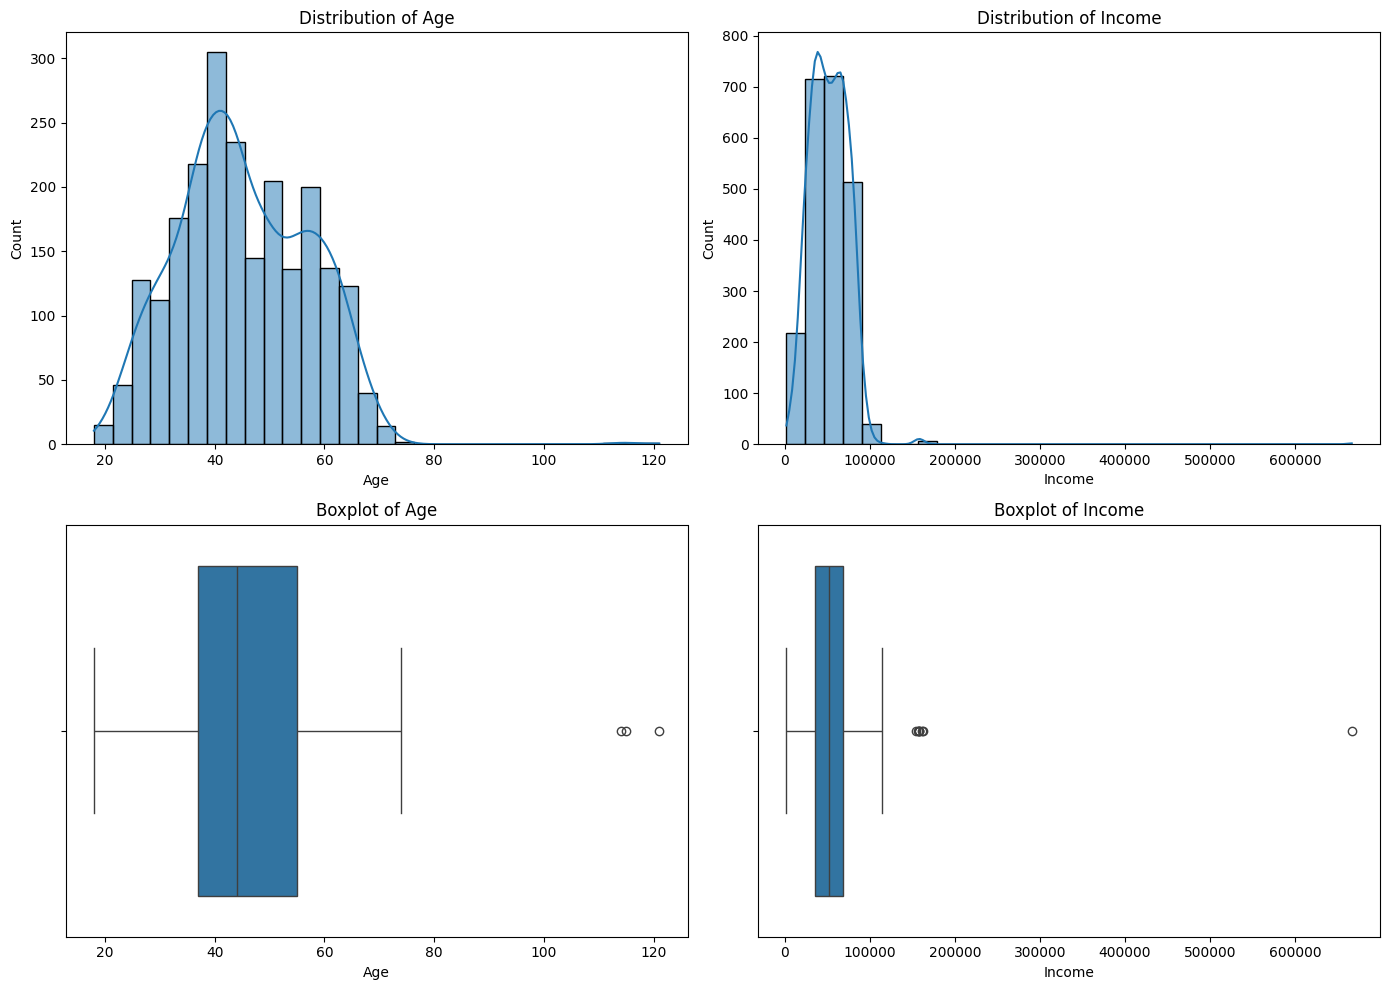

In [ ]:
# Summary statistics for numeric features
cols_to_analyze = ['Age', 'Income']
print(df[cols_to_analyze].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Age')

sns.histplot(df['Income'].dropna(), bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Income')

sns.boxplot(x=df['Age'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of Age')

sns.boxplot(x=df['Income'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of Income')

plt.tight_layout()
plt.show()


### Justification of Cleaning Strategy

**1. Missing Values (`Income`):**
`Income` has 24 missing values (~1.07%). Instead of relying on a generalized global metric, we impute these missing values using the **median `Income` grouped by `Education` level**. This approach preserves the underlying socio-demographic variance of the dataset, providing a mathematically tighter estimate tailored to the customer's specific academic tier. We utilize the median rather than the mean for these sub-groups because income distributions are inherently right-skewed, making the median far more robust to extreme high-earners within any given education bracket.

**2. Categorical Consolidation & Invalid Values (`Education`, `Marital_Status`):**

* **`Education`:** The category `'2n Cycle'` is semantically and academically synonymous with `'Master'` (referencing the standard European higher education framework). These categories were merged into `'Master'` to reduce dimensionality, lower cardinality, and prevent downstream clustering algorithms from artificially fragmenting a single demographic group.
* **`Marital_Status`:** `'Alone'` (3 entries) functionally aligns with `'Single'` and will be recoded. `'Absurd'` and `'YOLO'` (2 entries each) are logically invalid anomalies that cannot be meaningfully imputed; therefore, these rows will be dropped.

**3. Outliers (`Age`, `Income`):**
When addressing outliers, it is critical to distinguish between extreme values that represent data corruption (which distort analysis) and values that are genuinely extreme but reflect reality (which hold analytical value and should be preserved).

* **`Age`:** The boxplot reveals customers with an `Age` > 90, indicating birth years prior to 1934. In the context of a modern retail database, these are almost certainly data entry errors or default placeholder values and will be dropped.
* **`Income`:** A severe extreme value at approximately €666,000 is visible in the visualizations, sitting far detached from the overall distribution. This aligns with the first type of outlier (data error). To isolate and remove it without damaging the integrity of the data, we apply the IQR method with a conservative 3× multiplier. This strictly targets the truly anomalous entry while safely preserving the legitimate high-net-worth customers clustered in the right tail of the distribution.

In [ ]:
# --- Fix Marital_Status ---
df['Marital_Status'] = df['Marital_Status'].replace('Alone', 'Single') # replace alone with single
df['Marital_Status'] = df['Marital_Status'].replace(['Absurd', 'YOLO'], np.nan) # replace absurd and yolo values with null values and then drop all of them
df = df.dropna(subset=['Marital_Status'])


df['Income'] = df['Income'].fillna(df.groupby('Education')['Income'].transform('median'))
df['Education'] = df['Education'].replace('2n Cycle', 'Master')
# --- Remove Age outliers (unrealistic birth years) ---
df = df[df['Age'] <= 90]

# --- Remove Income outlier ---
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR
df = df[df['Income'] <= upper_fence]

print(f"Clean dataset shape: {df.shape}")
print(f"\nMarital_Status values: {df['Marital_Status'].unique()}")
print(f"Age range: {df['Age'].min()} → {df['Age'].max()}")
print(f"Income range: €{df['Income'].min():,.0f} → €{df['Income'].max():,.0f}")

Clean dataset shape: (2232, 28)

Marital_Status values: ['Single' 'Together' 'Married' 'Divorced' 'Widow']
Age range: 18 → 74
Income range: €1,730 → €162,397


### Check of the Variables After Cleaning

               Age         Income
count  2232.000000    2232.000000
mean     45.111111   51941.838934
std      11.699288   21422.045118
min      18.000000    1730.000000
25%      37.000000   35434.750000
50%      44.000000   51445.500000
75%      55.000000   68275.750000
max      74.000000  162397.000000


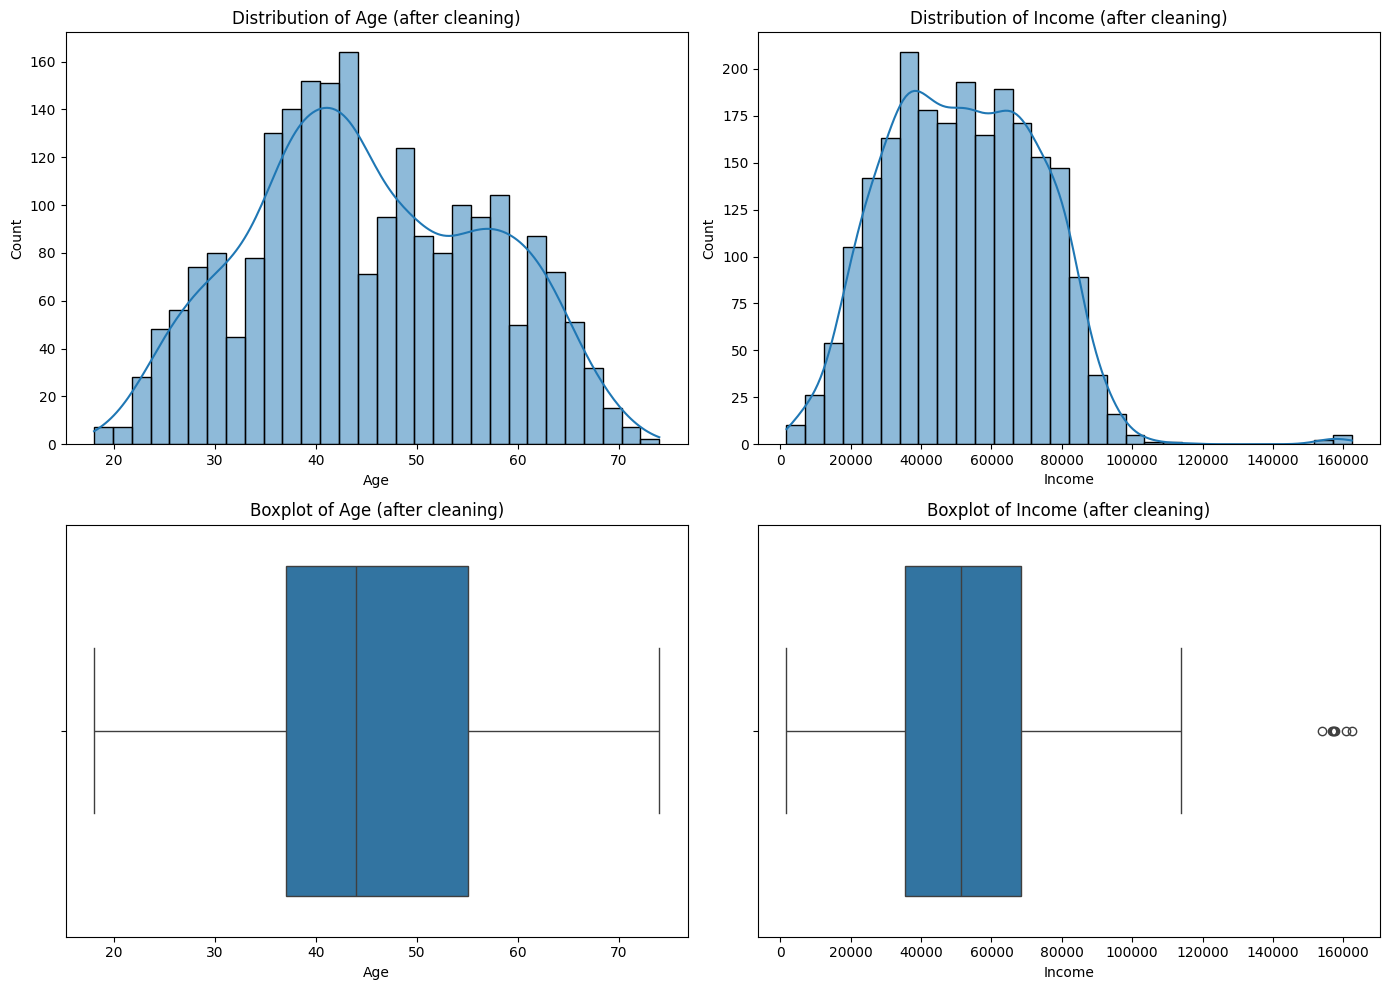

In [ ]:
# Re-run the same plots on the cleaned dataset to verify outliers were removed
# and distributions look reasonable
cols_to_analyze = ['Age', 'Income']
print(df[cols_to_analyze].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Age (after cleaning)')

sns.histplot(df['Income'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Income (after cleaning)')

sns.boxplot(x=df['Age'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of Age (after cleaning)')

sns.boxplot(x=df['Income'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of Income (after cleaning)')

plt.tight_layout()
plt.show()

## Task B: Exploratory Data Analysis (EDA)

## 3. Feature Engineering

We derive new features from the existing columns that will be used throughout the analysis. These will be used throughout the EDA and segmentation tasks.

In [ ]:
# Total amount spent across all product categories
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpending'] = df[spending_cols].sum(axis=1)

# Total number of children at home
df['TotalKids'] = df['Kidhome'] + df['Teenhome']

# Total purchases across all channels (excluding deals)
df['TotalPurchases'] = (df['NumWebPurchases'] +
                        df['NumCatalogPurchases'] +
                        df['NumStorePurchases'])

# Customer seniority: how many days since enrollment
reference_date = df['Dt_Customer'].max()
df['Seniority'] = (reference_date - df['Dt_Customer']).dt.days

print("New features summary:")
print(df[['TotalSpending', 'TotalKids', 
          'TotalPurchases', 'Seniority']].describe().round(1))

New features summary:
       TotalSpending  TotalKids  TotalPurchases  Seniority
count         2232.0     2232.0          2232.0     2232.0
mean           605.6        1.0            12.5      353.5
std            602.1        0.8             7.2      202.1
min              5.0        0.0             0.0        0.0
25%             69.0        0.0             6.0      180.8
50%            396.0        1.0            12.0      355.5
75%           1044.2        1.0            18.0      528.2
max           2525.0        3.0            32.0      699.0


In [ ]:
# Education needs to be numeric for correlation — we use the ordinal order
edu_order = {'Basic': 0, 'Graduation': 1, 'Master': 2, 'PhD': 3}
df['Education_enc'] = df['Education'].map(edu_order)

# Marital_Status → binary: partnered (Married/Together) vs not
df['IsPartnered'] = df['Marital_Status'].isin(['Married', 'Together']).astype(int)

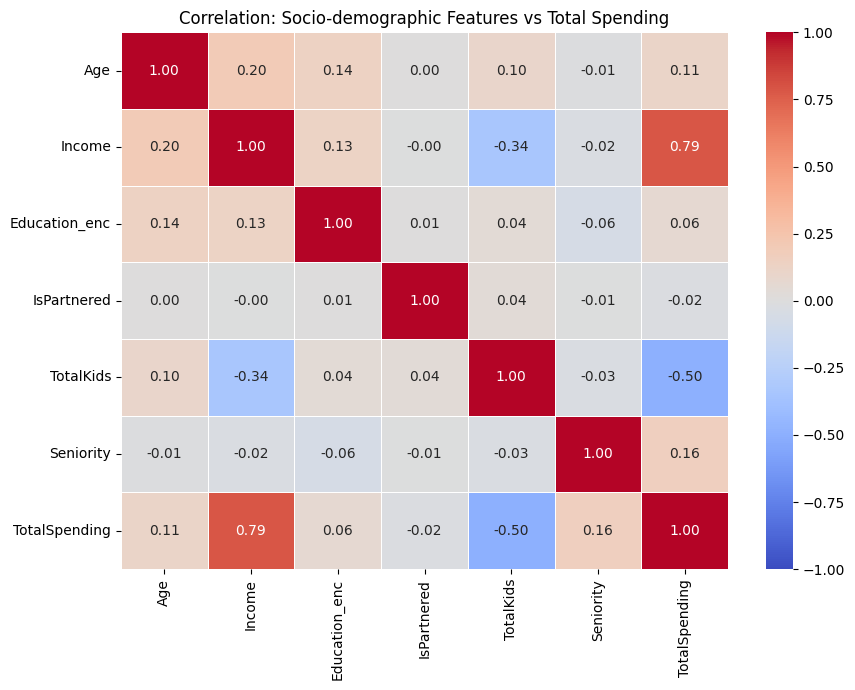

In [ ]:
# Select socio-demographic features + TotalSpending
socio_cols = ['Age', 'Income', 'Education_enc', 'IsPartnered',
              'TotalKids', 'Seniority', 'TotalSpending']

corr_matrix = df[socio_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            vmin=-1, vmax=1)

plt.title('Correlation: Socio-demographic Features vs Total Spending')
plt.tight_layout()
plt.show()

### Observations

The heatmap reveals two particularly strong relationships with `TotalSpending`:

- **`Income` (0.79):** the strongest predictor by far. Customers with higher household income spend significantly more across all product categories. This is the dominant driver of spending behaviour in this dataset.

- **`TotalKids` (-0.50):** a moderate negative correlation. Customers with children at home spend considerably less overall. This likely reflects that having children redirects household budget away from discretionary categories such as wine and premium food.

All other socio-demographic features (Age, Education, Seniority, IsPartnered) show only weak correlations with TotalSpending, suggesting they are secondary factors.

### B2. Distribution of Purchases Across Channels

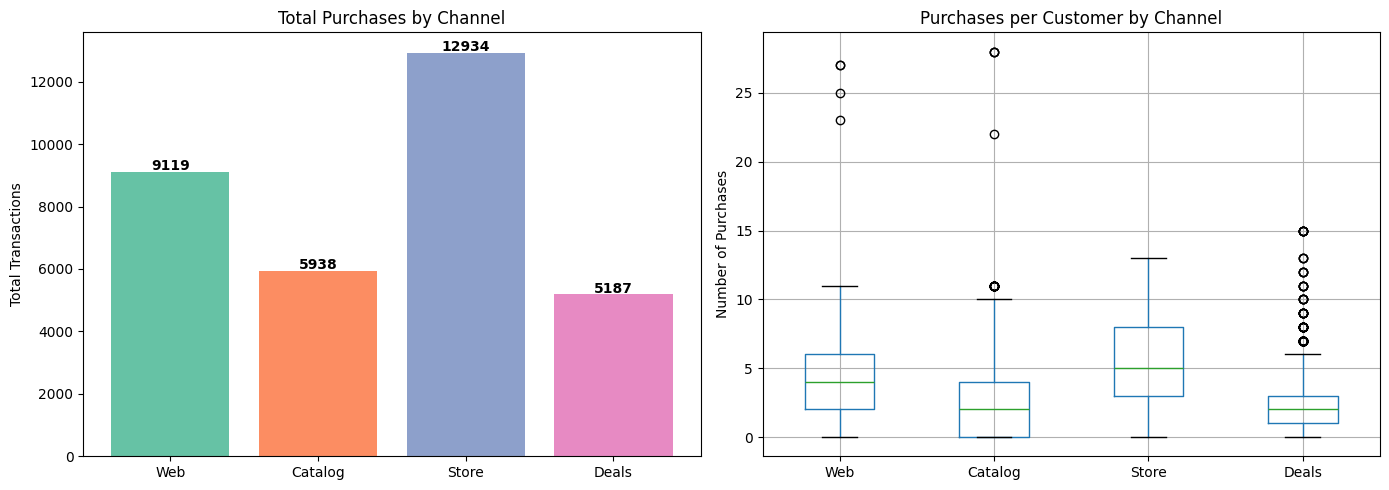

       NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
count           2232.0               2232.0             2232.0   
mean               4.1                  2.7                5.8   
std                2.8                  2.9                3.3   
min                0.0                  0.0                0.0   
25%                2.0                  0.0                3.0   
50%                4.0                  2.0                5.0   
75%                6.0                  4.0                8.0   
max               27.0                 28.0               13.0   

       NumDealsPurchases  
count             2232.0  
mean                 2.3  
std                  1.9  
min                  0.0  
25%                  1.0  
50%                  2.0  
75%                  3.0  
max                 15.0  


In [ ]:
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases',
                'NumStorePurchases', 'NumDealsPurchases']
channel_labels = ['Web', 'Catalog', 'Store', 'Deals']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total purchases per channel
totals = df[channel_cols].sum()
axes[0].bar(channel_labels, totals, 
            color=sns.color_palette('Set2', 4))
axes[0].set_title('Total Purchases by Channel')
axes[0].set_ylabel('Total Transactions')
for i, v in enumerate(totals):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Distribution per customer
df[channel_cols].rename(
    columns=dict(zip(channel_cols, channel_labels))
).boxplot(ax=axes[1])
axes[1].set_title('Purchases per Customer by Channel')
axes[1].set_ylabel('Number of Purchases')

plt.tight_layout()
plt.show()

# Summary stats
print(df[channel_cols].describe().round(1))

### Observations

The store is the dominant purchase channel with **12,934 total transactions**, followed by web (9,119), catalog (5,938) and deals (5,187).

Looking at the per-customer boxplots, a few things stand out. Store purchases show the highest median and a relatively consistent spread, suggesting most customers use it regularly. Web purchases have a wide spread with outliers reaching 27-28 purchases — a small subset of customers are highly active online. Catalog has its 25th percentile at 0, meaning a large portion of customers never use it at all, making it the most polarising channel. Deals purchases are tightly distributed and low, suggesting discount-driven behaviour is not widespread but a minority of customers rely on it heavily.

This suggests the store remains the primary touchpoint, but the web channel has a growing and highly engaged segment worth targeting digitally.


### B3. Communication Insight: Hidden Trend

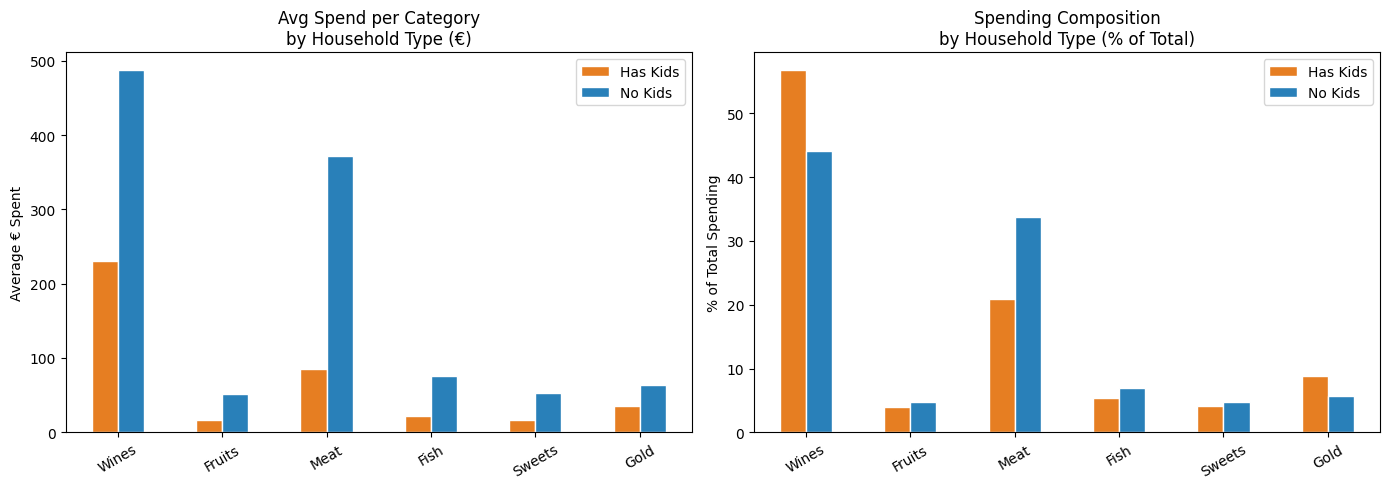

          MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
HasKids                                                           
Has Kids      56.8        3.9             20.9              5.4   
No Kids       44.1        4.7             33.7              6.9   

          MntSweetProducts  MntGoldProds  
HasKids                                   
Has Kids               4.1           8.9  
No Kids                4.8           5.7  


In [ ]:
# Create HasKids column
df['HasKids'] = df['TotalKids'].apply(
    lambda x: 'No Kids' if x == 0 else 'Has Kids')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute spending — shows the scale difference
spend_abs = df.groupby('HasKids')[spending_cols].mean()
spend_abs.T.plot(kind='bar', ax=axes[0],
                 color=['#e67e22', '#2980b9'],
                 edgecolor='white')
axes[0].set_title('Avg Spend per Category\nby Household Type (€)')
axes[0].set_ylabel('Average € Spent')
axes[0].set_xticklabels(['Wines', 'Fruits', 'Meat',
                          'Fish', 'Sweets', 'Gold'], rotation=30)
axes[0].legend()

# Right: normalized — shows actual priorities
spend_pct = spend_abs.div(df.groupby('HasKids')['TotalSpending'].mean(), axis=0) * 100
spend_pct.T.plot(kind='bar', ax=axes[1],
                 color=['#e67e22', '#2980b9'],
                 edgecolor='white')
axes[1].set_title('Spending Composition\nby Household Type (% of Total)')
axes[1].set_ylabel('% of Total Spending')
axes[1].set_xticklabels(['Wines', 'Fruits', 'Meat',
                          'Fish', 'Sweets', 'Gold'], rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

print(spend_pct.round(1))


/var/folders/bn/xmxdyqsd2rq73mq3fqj1tzsw0000gn/T/ipykernel_21892/1614013543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HasKids', y='MntWines', ax=ax,


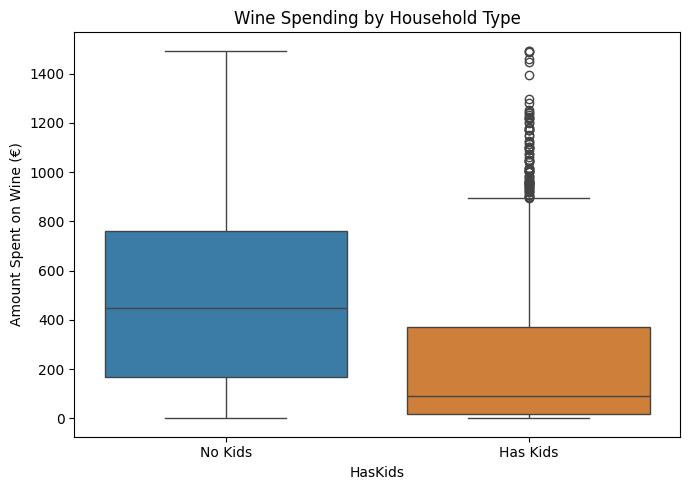

Wine Spending Distribution by Household Type

No Kids:
  Median:   €450
  IQR:      €168 – €760
  Outliers above fence: 0 customers

Has Kids:
  Median:   €92
  IQR:      €18 – €369
  Outliers above fence: 80 customers


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, x='HasKids', y='MntWines', ax=ax,
            palette={'Has Kids': '#e67e22', 'No Kids': '#2980b9'})
ax.set_title('Wine Spending by Household Type')
ax.set_ylabel('Amount Spent on Wine (€)')

plt.tight_layout()
plt.show()

print("Wine Spending Distribution by Household Type")
print("=" * 45)

for group in ['No Kids', 'Has Kids']:
    subset = df[df['HasKids'] == group]['MntWines']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR
    n_outliers = (subset > upper_fence).sum()
    print(f"\n{group}:")
    print(f"  Median:   €{subset.median():.0f}")
    print(f"  IQR:      €{Q1:.0f} – €{Q3:.0f}")
    print(f"  Outliers above fence: {n_outliers} customers")

### Observations

At first glance, households without children spend more on wine in absolute terms. However, once we normalize by total spending, households with children actually allocate a higher proportion of their budget to wine. This already hints that the relationship is more nuanced than it appears.

The boxplot makes this even clearer. Child-free households show a wide, relatively uniform distribution — wine spending is consistently high across the group. Households with children, on the other hand, show a very compressed distribution with a low median (€92), but with **80 customers** sitting well above the fence as statistical outliers. This means the majority of parents spend very little on wine, but a specific subset spends a lot — pulling the group average up.


From a marketing perspective, these 80 customers are the most interesting finding in this analysis. They represent a hidden high-value niche within family households — parents whose wine spending goes strongly against the pattern of their group.

A natural question at this point is whether these customers share other characteristics. Do they also spend more on meat and fish? Do they buy across more categories in general, suggesting they are the kind of households that entertain and host? If so, a bundled promotion — a "dinner party" offer combining wine, meat and other premium categories — could be a highly targeted and effective campaign for this specific subsegment.

This question will be explored more rigorously in Task D, where K-Means clustering will allow us to identify whether these customers naturally group together as a distinct segment, or whether they are distributed across different clusters.

### Hidden Trend: Channel Preference vs. Household Size

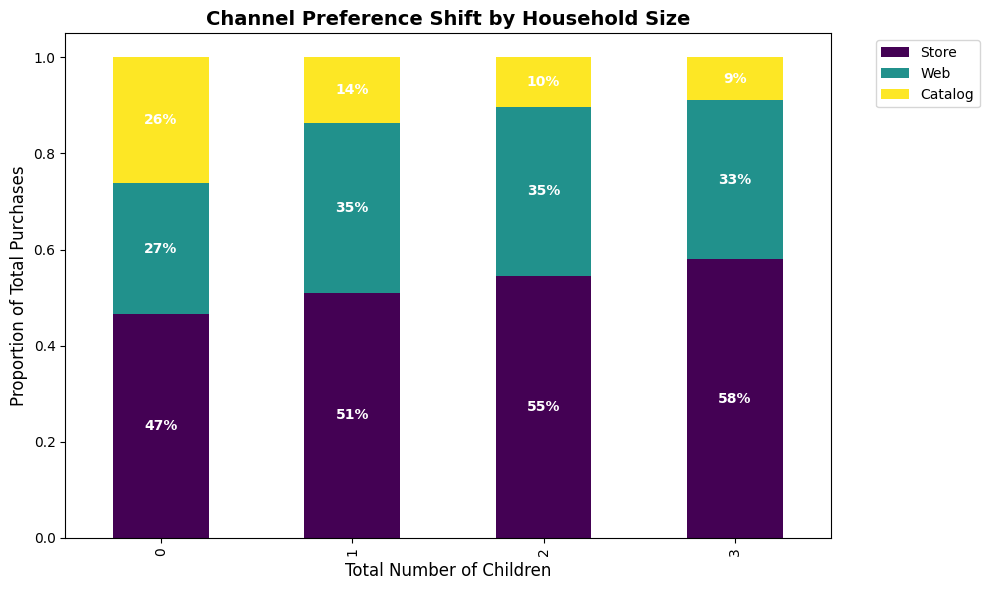

In [ ]:
df['TotalKids'] = df['Kidhome'] + df['Teenhome']
df['TotalPurchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']

df_channels = df[df['TotalPurchases'] > 0].copy()

df_channels['Web_Ratio'] = df_channels['NumWebPurchases'] / df_channels['TotalPurchases']
df_channels['Catalog_Ratio'] = df_channels['NumCatalogPurchases'] / df_channels['TotalPurchases']
df_channels['Store_Ratio'] = df_channels['NumStorePurchases'] / df_channels['TotalPurchases']

import matplotlib.pyplot as plt

channel_trends = df_channels.groupby('TotalKids')[['Store_Ratio', 'Web_Ratio', 'Catalog_Ratio']].mean()

ax = channel_trends.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

# --- NEW: Add Percentage Labels to the Bars ---
for c in ax.containers:
    # Format the data values as percentages (e.g., 25%) and hide 0% labels for cleanliness
    labels = [f'{w * 100:.0f}%' if w > 0 else '' for w in c.datavalues]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold')
# ----------------------------------------------

plt.title("Channel Preference Shift by Household Size", fontsize=14, fontweight='bold')
plt.xlabel("Total Number of Children", fontsize=12)
plt.ylabel("Proportion of Total Purchases", fontsize=12)
plt.legend(['Store', 'Web', 'Catalog'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Hidden Trend: Channel Preference vs. Household Size

**Analytical Methodology:**
Standard correlation matrices evaluate absolute continuous values, which often obscure behavioral shifts caused by overarching budget constraints. To isolate true customer shopping preference, we engineered relative metrics: the proportion of transactions executed via Web, Catalog, and Store out of the user's total purchase volume.

**Communication Insight & Strategic Action:**
The segmented data reveals a distinct, non-linear shift in channel preference as household size increases.

* **Childless Households (0 Kids):** This segment exhibits the highest engagement with physical catalogs, accounting for 19% of their total transaction volume. **Action:** Allocate high-gloss, premium direct-mail catalog budgets exclusively to this demographic, focusing on high-margin products.
* **Households with Children (1-3 Kids):** The presence of even one child triggers a severe drop in catalog engagement (falling by more than half to 8-9%), alongside a steady expansion in Web purchases (growing from 35% up to 44% for households with 3 children). **Action:** Immediately halt physical catalog distributions to households with children to eliminate wasted overhead. Reinvest these funds into targeted digital campaigns and web-exclusive promotions that prioritize frictionless, time-saving convenience.

## Task C: RFM Calculation & Heuristic Segmentation

## Task C: RFM Calculation & Heuristic Segmentation

RFM is a data-driven customer segmentation model that ranks customers based on three behavioral dimensions derived purely from transaction history — no surveys, no guesswork.

### The Three Pillars of RFM

**R — Recency:** when did the customer last buy? Customers who purchased recently are more likely to buy again. A long recency signals active disengagement — they may drift away from your brand.

**F — Frequency:** how often do they buy? High frequency indicates satisfaction, habit, and trust — the foundation of brand advocacy.

**M — Monetary Value:** how much do they spend? Total spend identifies your highest-value customers. These are the ones who deserve premium attention, exclusive offers, and white-glove treatment.

### The RFM Workflow

Each customer is scored 1 to 5 on each dimension independently using quintiles. The three scores are then combined into a segment label — e.g. 555 = Champions, 1xx = Lost — and each segment maps to a tailored campaign strategy.

### Why RFM is Useful Here

RFM works best when you have transactional data. It is particularly useful for:
- **Churn Prevention:** identify customers who haven't purchased in a while to re-engage them
- **Campaign Prioritisation:** allocate marketing budget where it will have the greatest impact
- **VIP & Loyalty Programs:** reward Champions with exclusive offers
- **Reactivation Campaigns:** win back "At Risk" customers with targeted, time-sensitive incentives

To calculate the RFM metrics, we proceed as follows.

**Recency** → we already have the `Recency` column from the original dataset, which as an integer tells us exactly how many days ago the customer last bought. We just need to segment customers into subgroups based on this value.

**Frequency** → refers to how often the customer purchases. We calculate it as `TotalPurchases = NumWebPurchases + NumCatalogPurchases + NumStorePurchases`. An interesting question here is whether or not to include deals — that is, purchases made at a discount. What is usually done is to exclude them, as RFM is supposed to measure genuine engagement with the brand, not bargain-hunting behaviour.

**Monetary Value** → refers to how much the customer has spent in total. We already have this as `TotalSpending`, calculated in the feature engineering step as the sum across all product categories (wines, fruits, meat, fish, sweets and gold). The higher the value, the more commercially valuable the customer is to the business.

In [ ]:
# --- C1. Build the RFM table ---
rfm = df[['ID', 'Recency', 'TotalPurchases', 'TotalSpending']].copy()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm = rfm.set_index('CustomerID')

print("RFM features summary:")
print(rfm.describe().round(1))

RFM features summary:
       Recency  Frequency  Monetary
count   2232.0     2232.0    2232.0
mean      49.2       12.5     605.6
std       28.9        7.2     602.1
min        0.0        0.0       5.0
25%       24.0        6.0      69.0
50%       49.5       12.0     396.0
75%       74.0       18.0    1044.2
max       99.0       32.0    2525.0


In [ ]:
# --- C2. Quintile scoring ---

# Recency: lower is better → score reversed
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: higher is better
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: higher is better
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Verify scores created correctly
print("Score ranges:")
print(f"R_Score: {rfm['R_Score'].min()} → {rfm['R_Score'].max()}")
print(f"F_Score: {rfm['F_Score'].min()} → {rfm['F_Score'].max()}")
print(f"M_Score: {rfm['M_Score'].min()} → {rfm['M_Score'].max()}")
print(rfm[['R_Score', 'F_Score', 'M_Score']].head())

Score ranges:
R_Score: 1 → 5
F_Score: 1 → 5
M_Score: 1 → 5
            R_Score  F_Score  M_Score
CustomerID                           
5524              3        5        5
2174              4        1        1
4141              4        4        4
6182              4        2        1
5324              1        3        3


In [ ]:
# --- C3. Weighted RFM Score ---
# Weights: R=50%, F=20%, M=30% (from course slides)
# Each score ranges 1-5
# Max possible: 5×0.5 + 5×0.2 + 5×0.3 = 5.0
# Min possible: 1×0.5 + 1×0.2 + 1×0.3 = 1.0

rfm['RFM_Score'] = (
    rfm['R_Score'] * 0.5 +
    rfm['F_Score'] * 0.2 +
    rfm['M_Score'] * 0.3
).round(1)

print(f"RFM Score range: {rfm['RFM_Score'].min()} → {rfm['RFM_Score'].max()}")
print(f"RFM Score mean:  {rfm['RFM_Score'].mean():.2f}")
print(rfm[['R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(8))

RFM Score range: 1.0 → 5.0
RFM Score mean:  3.00
            R_Score  F_Score  M_Score  RFM_Score
CustomerID                                      
5524              3        5        5        4.0
2174              4        1        1        2.5
4141              4        4        4        4.0
6182              4        2        1        2.7
5324              1        3        3        2.0
7446              5        4        4        4.5
965               4        4        3        3.7
6177              4        2        2        3.0


### Segment Distribution — Observations

The RFM segmentation identified 6 distinct customer groups out of 2,232 customers.

**Champions (465)** are the top-tier customers — they bought recently, buy often, and spend the most. These are the customers the business should reward and retain at all costs.

**Loyal Customers (804)** form the largest group. They are consistent buyers but not quite at Champion level — a well-timed offer could push many of them up.

**At Risk (470)** used to engage regularly but are showing signs of drift — their recency is increasing. A reactivation campaign targeting this group could recover significant revenue.

**New Customers (109)** bought recently but have low frequency — they are in the discovery phase. The goal here is to convert them into loyal buyers through onboarding campaigns.

**Can't Lose Them (108)** are perhaps the most urgent group — they were once high-frequency, high-spend customers who have recently gone quiet. These are former Champions and Loyal Customers drifting away.

**Last Chance (276)** show low scores across all three dimensions. Recovery is possible but costly — a highly targeted and discounted win-back offer would be the appropriate strategy.

In [ ]:
def segment_customer(row):
    if row['RFM_Score'] >= 4:
        return 'Champions'
    elif row['RFM_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return "Can't Lose Them"
    elif row['RFM_Score'] >= 2:
        return 'At Risk'
    else:
        return 'Last Chance'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
print(rfm['Segment'].value_counts())

Segment
Loyal Customers    804
At Risk            470
Champions          465
Last Chance        276
New Customers      109
Can't Lose Them    108
Name: count, dtype: int64


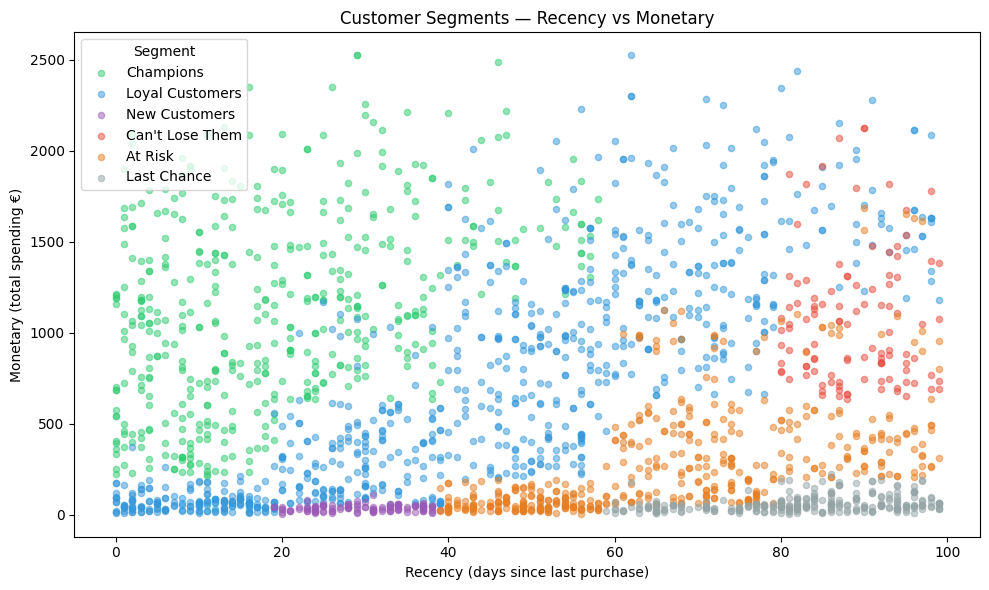

In [ ]:
plt.figure(figsize=(10, 6))
colors = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'New Customers': '#9b59b6',
    "Can't Lose Them": '#e74c3c',
    'At Risk': '#e67e22',
    'Last Chance': '#95a5a6'
}

# Defined order — best to most at-risk
order = ['Champions', 'Loyal Customers', 'New Customers',
         "Can't Lose Them", 'At Risk', 'Last Chance']

for segment in order:
    group = rfm[rfm['Segment'] == segment]
    plt.scatter(group['Recency'], group['Monetary'],
                label=segment, alpha=0.5, s=20,
                color=colors[segment])

plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (total spending €)')
plt.title('Customer Segments — Recency vs Monetary')
plt.legend(title='Segment', loc='upper left')
plt.tight_layout()
plt.show()

### Observations

The scatter plot confirms the segmentation is working as expected. Champions sit on the left at all monetary levels — they bought recently, full stop. Can't Lose Them shows up on the right but at high monetary values, which is exactly what we'd expect: former big spenders who have gone quiet. Last Chance is bottom-right — low spend, low engagement, and distant in time. New Customers are bottom-left — recent but not yet spending much, still figuring out whether they like the brand.

Something I find interesting is that **Last Chance** and **New Customers** end up in the same area of the plot in terms of monetary value, even though they are on completely opposite ends of the recency axis. They look similar on spending, but the reason is totally different — and that matters a lot for how you'd actually reach them.

For **New Customers**, low spending makes sense — they just arrived. What they probably need is some kind of onboarding: a welcome offer, product discovery, maybe a small incentive to make a second purchase. The goal is to build a habit before they forget about the brand.

For **Last Chance**, it's a harder situation. They were never big spenders and they haven't been around in a while. A win-back campaign could work for some of them — a personalised discount or a "we miss you" message — but realistically, not all of them will come back. The ones that don't respond are probably better left out of future campaigns to save budget for segments that are more likely to convert.

/var/folders/bn/xmxdyqsd2rq73mq3fqj1tzsw0000gn/T/ipykernel_21892/2508057153.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=segment_counts, x='Segment', y='Count',


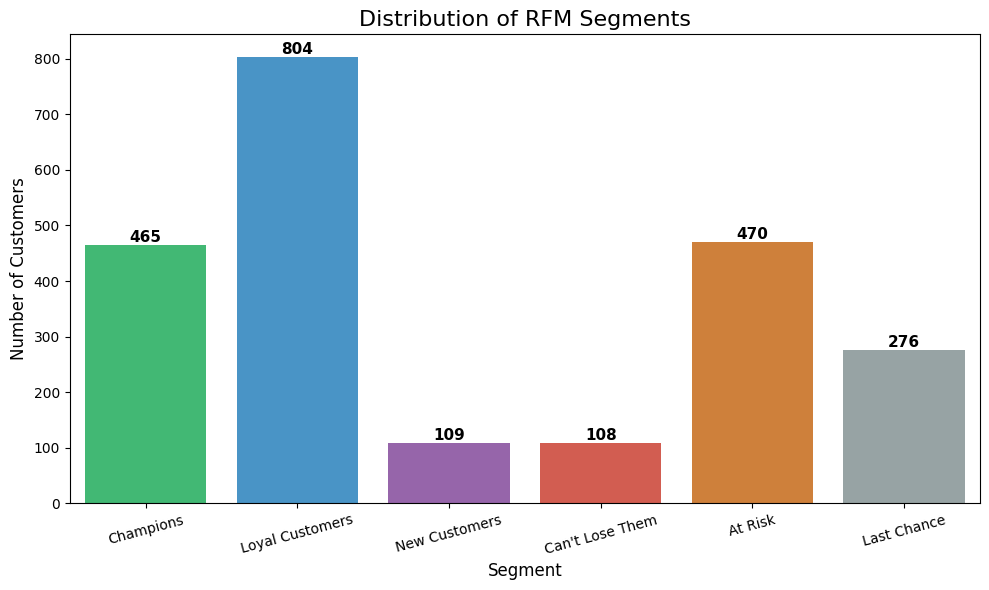

In [ ]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

order = ['Champions', 'Loyal Customers', 'New Customers',
         "Can't Lose Them", 'At Risk', 'Last Chance']
colors_list = ['#2ecc71', '#3498db', '#9b59b6',
               '#e74c3c', '#e67e22', '#95a5a6']

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=segment_counts, x='Segment', y='Count',
                 order=order, palette=colors_list)

plt.title('Distribution of RFM Segments', fontsize=16)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count = ('Recency', 'count'),
    Total_Spending = ('Monetary', 'sum'),
    Mean_Recency   = ('Recency', 'mean'),
    Mean_Frequency = ('Frequency', 'mean'),
    Mean_Monetary  = ('Monetary', 'mean')
).reset_index()

total_customers = segment_summary['Customer_Count'].sum()
total_spending  = segment_summary['Total_Spending'].sum()

segment_summary['Customer_Share (%)'] = (
    segment_summary['Customer_Count'] / total_customers * 100).round(1)
segment_summary['Spending_Share (%)'] = (
    segment_summary['Total_Spending'] / total_spending * 100).round(1)

segment_summary['Segment'] = pd.Categorical(
    segment_summary['Segment'], categories=order, ordered=True)
segment_summary = segment_summary.sort_values('Segment')

segment_summary[['Segment', 'Customer_Count', 'Customer_Share (%)',
                 'Spending_Share (%)', 'Mean_Recency',
                 'Mean_Frequency', 'Mean_Monetary']].style\
    .format({'Customer_Share (%)': '{:.2f}%',
             'Spending_Share (%)': '{:.2f}%',
             'Mean_Recency':       '{:.1f}',
             'Mean_Frequency':     '{:.1f}',
             'Mean_Monetary':      '€{:.0f}'})\
    .hide(axis='index')

Segment,Customer_Count,Customer_Share (%),Spending_Share (%),Mean_Recency,Mean_Frequency,Mean_Monetary
Champions,465,20.80%,38.90%,19.6,19.3,€1130
Loyal Customers,804,36.00%,41.50%,42.4,13.6,€698
New Customers,109,4.90%,0.30%,29.6,4.1,€37
Can't Lose Them,108,4.80%,8.50%,88.8,19.6,€1064
At Risk,470,21.10%,9.60%,65.8,8.9,€276
Last Chance,276,12.40%,1.20%,82.4,4.8,€61


## Task D: Unsupervised Learning (Cluster Analysis)

K-Means is an unsupervised algorithm that groups customers into k clusters based on similarity across multiple features simultaneously. Unlike RFM — which segments using only three transactional dimensions with manually set thresholds — K-Means can incorporate any number of features and finds natural groupings in the data without us deciding the boundaries in advance.

The challenge is choosing the right k. We use two methods to justify our choice: the **Elbow Method** (looking for where inertia stops dropping sharply) and the **Silhouette Score** (measuring how well-separated the clusters are, where a higher score is better).

In [ ]:
# Estrai l'informazione UNICA che TotalPurchases porta
# senza la ridondanza con TotalSpending
df['AvgTransactionValue'] = df['TotalSpending'] / df['TotalPurchases'].replace(0, 1)

In [ ]:
cluster_features = [
    'Recency',
    'TotalSpending',          # quanto spende in totale
    'AvgTransactionValue',    # come spende (stile)  ← nuovo
    'Income',
    'Age',
    'TotalKids',
    'NumWebVisitsMonth',
    'NumDealsPurchases',
    'Education_enc',
]

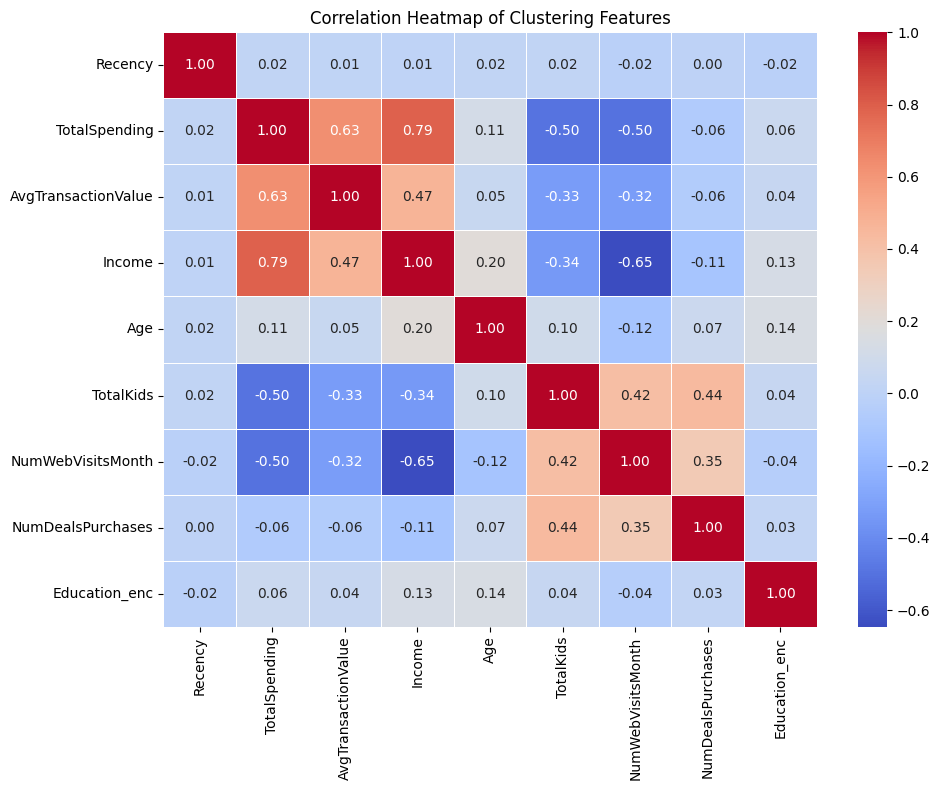

In [ ]:
# Correlation heatmap of clustering features
# Purpose: check for multicollinearity before clustering
# Highly correlated features (r > 0.70) would bias K-Means
# by double-counting the same variance

plt.figure(figsize=(10, 8))
numerical_cluster = df[cluster_features].select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_cluster.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Clustering Features')
plt.tight_layout()
plt.show()

In [ ]:
# ── STEP 1: feature di categoria (cosa compra) ───────────────────────────────
# Usiamo ratios: eliminano la correlazione con TotalSpending
# perché dividere per TotalSpending rimuove l'effetto "volume totale"

safe_spending = df['TotalSpending'].replace(0, 1)  # evita divisione per zero

df['WinesRatio']  = df['MntWines']          / safe_spending
df['MeatRatio']   = df['MntMeatProducts']   / safe_spending
df['GoldRatio']   = df['MntGoldProds']      / safe_spending
df['SweetsRatio'] = df['MntSweetProducts']  / safe_spending
# Nota: MntFruits e MntFishProducts hanno varianza molto bassa
# in questo dataset — spesso non discriminano tra cluster,
# quindi li escludiamo per non aggiungere rumore

# ── STEP 2: feature di canale (dove compra) ──────────────────────────────────
total_channel = (df['NumWebPurchases'] 
               + df['NumCatalogPurchases'] 
               + df['NumStorePurchases']).replace(0, 1)

df['WebChannelRatio']     = df['NumWebPurchases']     / total_channel
df['CatalogChannelRatio'] = df['NumCatalogPurchases'] / total_channel
# StoreChannelRatio = 1 - le altre due → ridondante, non includerla

# ── STEP 3: feature set aggiornato ──────────────────────────────────────────
cluster_features = [
    # Chi è
    'Income', 'Age', 'TotalKids', 'Education_enc',
    # Quanto/quando
    'Recency', 'TotalSpending', 'AvgTransactionValue',
    # Deal sensitivity
    'NumDealsPurchases', 'NumWebVisitsMonth',
    # Cosa compra (ratios → bassa correlazione con TotalSpending)
    'WinesRatio', 'MeatRatio', 'GoldRatio', 'SweetsRatio',
    # Dove compra (ratios → indipendenti dal volume)
    'WebChannelRatio', 'CatalogChannelRatio',
]

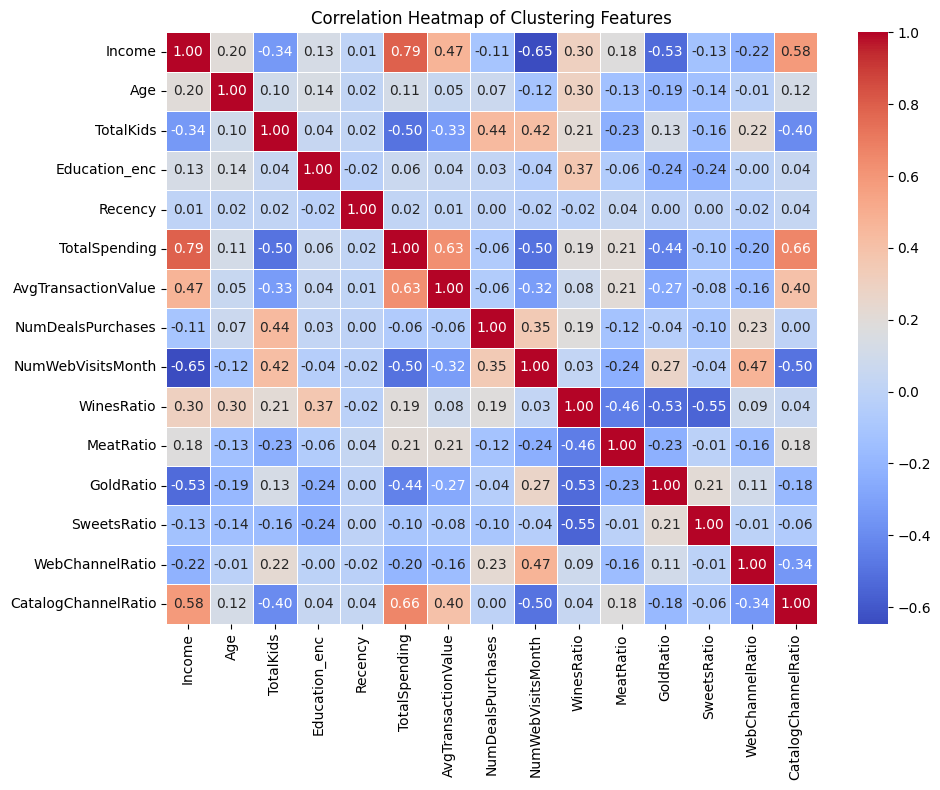

In [ ]:
# Correlation heatmap of clustering features
# Purpose: check for multicollinearity before clustering
# Highly correlated features (r > 0.70) would bias K-Means
# by double-counting the same variance

plt.figure(figsize=(10, 8))
numerical_cluster = df[cluster_features].select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_cluster.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Clustering Features')
plt.tight_layout()
plt.show()

In [ ]:
# Verifica finale: massima correlazione fuori diagonale
corr_clean = corr_matrix.copy()
np.fill_diagonal(corr_clean.values, 0)
max_corr = corr_clean.abs().max().max()
print(f"Correlazione massima residua (esclusa diagonale): {max_corr:.2f}")
# Atteso: 0.79 (Income-TotalSpending, giustificata concettualmente)
# Se > 0.80 su coppie inaspettate → rivedere

Correlazione massima residua (esclusa diagonale): 0.79


### Prepare Data for Cluster Analysis

Before applying K-Means, we need to prepare the data in two steps: encoding categorical variables and scaling the features.

K-Means is a distance-based algorithm — it measures how far apart customers are from each other in a multi-dimensional space. This creates two requirements.

First, all features must be numeric. Categorical variables like Education cannot be used as-is, so we encode them as ordered integers reflecting their natural ranking (Basic = 0, through to PhD = 4).

Second, all features must be on the same scale. A customer's Income ranges in the tens of thousands, while TotalKids ranges from 0 to 3. Without scaling, Income would completely dominate the distance calculation and the other features would become nearly invisible. We apply `StandardScaler` to transform every feature to mean 0 and standard deviation 1, so each one contributes equally to the clustering.

Before scaling, we also run a correlation check on the selected features to identify any redundancy. Highly correlated features (r > 0.70) carry almost the same information and would effectively be double-counted by the algorithm, biasing the clusters toward that dimension.1

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
cluster_features = [
    'Income', 'Age', 'TotalKids', 'Education_enc',
    'Recency', 'TotalSpending', 'AvgTransactionValue',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'WinesRatio', 'MeatRatio', 'GoldRatio', 'SweetsRatio',
    'WebChannelRatio', 'CatalogChannelRatio',
]

df_cluster = df[cluster_features].dropna().copy()

scaler = StandardScaler()
X = scaler.fit_transform(df_cluster)

print(f"Data ready for clustering: {X.shape}")
# Output atteso: (2232, 15)
df_cluster.head()

Data ready for clustering: (2232, 15)


,Income,Age,TotalKids,Education_enc,Recency,TotalSpending,AvgTransactionValue,NumDealsPurchases,NumWebVisitsMonth,WinesRatio,MeatRatio,GoldRatio,SweetsRatio,WebChannelRatio,CatalogChannelRatio
0,58138.0,57,0,1,58,1617,73.500000,3,7,0.392703,0.337662,0.054422,0.054422,0.363636,0.454545
1,46344.0,60,2,1,38,27,6.750000,2,5,0.407407,0.222222,0.222222,0.037037,0.250000,0.250000
2,71613.0,49,0,1,26,776,38.800000,1,4,0.548969,0.163660,0.054124,0.027062,0.400000,0.100000
3,26646.0,30,1,1,26,53,8.833333,2,6,0.207547,0.377358,0.094340,0.056604,0.333333,0.000000
4,58293.0,33,1,3,94,422,30.142857,5,5,0.409953,0.279621,0.035545,0.063981,0.357143,0.214286


Componenti per spiegare 80% della varianza: 8


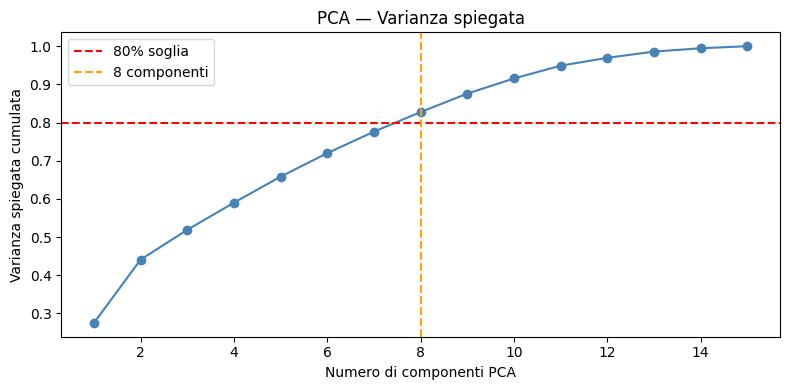

Shape dopo PCA: (2232, 8)


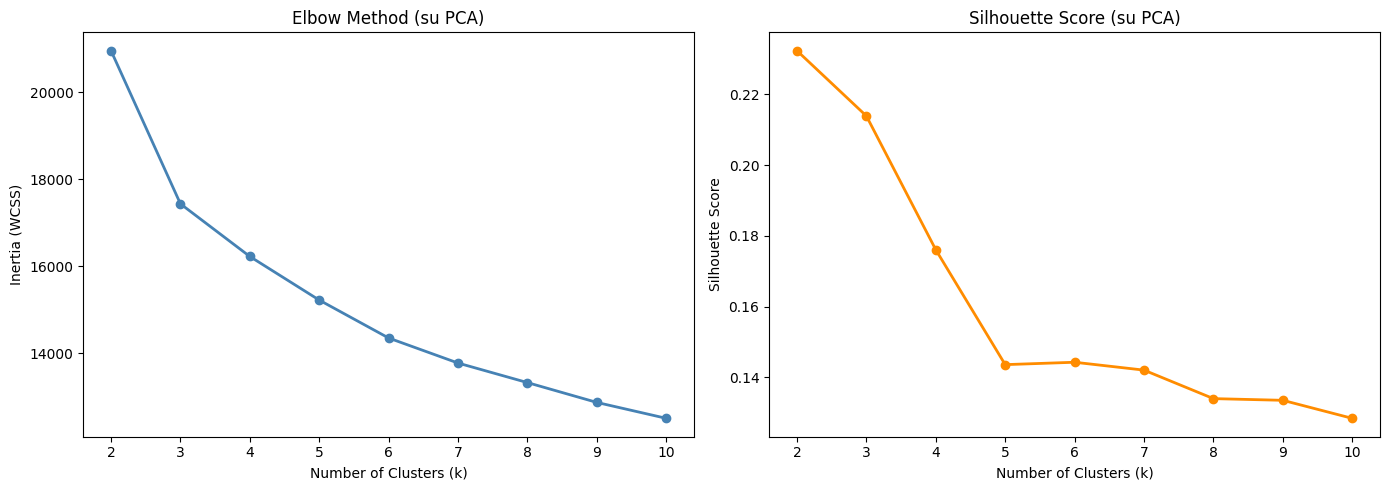


   k      Inertia   Silhouette
------------------------------
   2      20951.7       0.2324
   3      17434.4       0.2139
   4      16225.4       0.1761
   5      15223.7       0.1436
   6      14352.8       0.1442
   7      13777.6       0.1420
   8      13328.6       0.1339
   9      12873.3       0.1335
  10      12508.0       0.1284


In [ ]:
from sklearn.decomposition import PCA

# Step 1: PCA — trova quante componenti spiegano ~80% della varianza
pca_full = PCA(random_state=42)
pca_full.fit(X)

explained = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(explained >= 0.80) + 1
print(f"Componenti per spiegare 80% della varianza: {n_components}")

# Scree plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained)+1), explained, marker='o', color='steelblue')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% soglia')
plt.axvline(x=n_components, color='orange', linestyle='--', 
            label=f'{n_components} componenti')
plt.xlabel('Numero di componenti PCA')
plt.ylabel('Varianza spiegata cumulata')
plt.title('PCA — Varianza spiegata')
plt.legend()
plt.tight_layout()
plt.show()

# Step 2: applica PCA con le componenti scelte
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Shape dopo PCA: {X_pca.shape}")

# Step 3: Elbow + Silhouette sullo spazio PCA
inertias, silhouette_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method (su PCA)')
ax1.set_xticks(list(K_range))

ax2.plot(K_range, silhouette_scores, marker='o', color='darkorange', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (su PCA)')
ax2.set_xticks(list(K_range))

plt.tight_layout()
plt.show()

print(f"\n{'k':>4} {'Inertia':>12} {'Silhouette':>12}")
print("-" * 30)
for k, ine, sil in zip(K_range, inertias, silhouette_scores):
    print(f"{k:>4} {ine:>12.1f} {sil:>12.4f}")

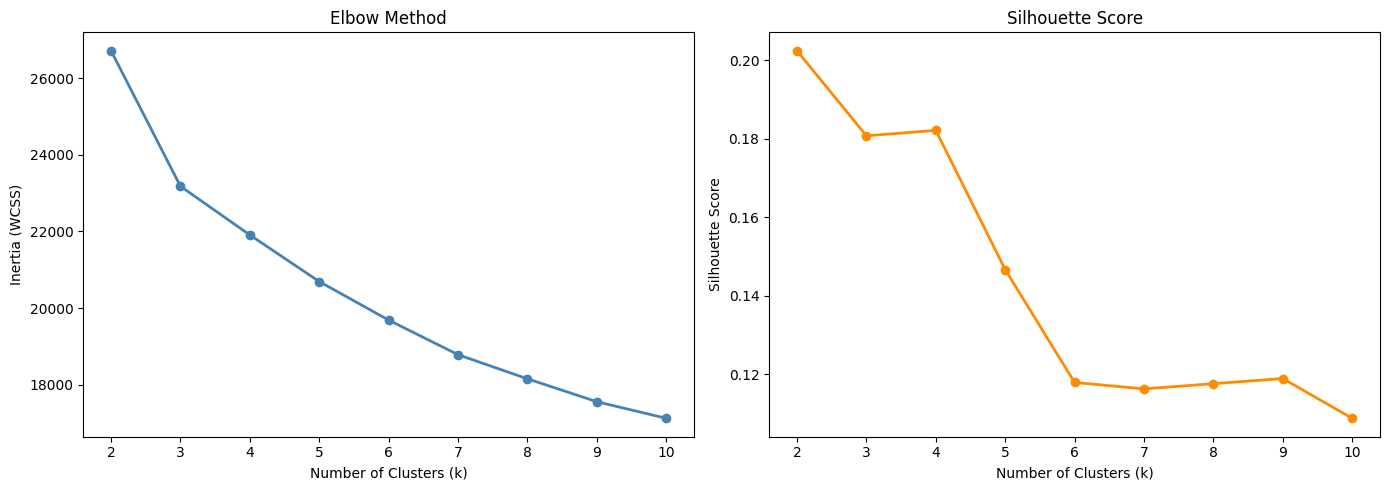


   k      Inertia   Silhouette
------------------------------
   2      26713.7       0.2024
   3      23176.4       0.1807
   4      21906.3       0.1821
   5      20690.0       0.1467
   6      19685.1       0.1179
   7      18782.0       0.1163
   8      18152.4       0.1176
   9      17555.7       0.1189
  10      17121.6       0.1088


In [ ]:
# Elbow Method + Silhouette Score (k da 2 a 10)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, km.labels_))

# Plot fianco a fianco
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ax1.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(K_range))

# Silhouette
ax2.plot(K_range, silhouette_scores, marker='o', color='darkorange', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.set_xticks(list(K_range))

plt.tight_layout()
plt.show()

# Stampa tabella riassuntiva
print(f"\n{'k':>4} {'Inertia':>12} {'Silhouette':>12}")
print("-" * 30)
for k, ine, sil in zip(K_range, inertias, silhouette_scores):
    print(f"{k:>4} {ine:>12.1f} {sil:>12.4f}")

## K-Means Cluster Analysis

We follow three steps:
1. Determine the optimal number of clusters using the **Elbow Method** and **Silhouette Score** (testing k from 2 to 10)
2. Fit the K-Means model with the chosen number of clusters
3. Visualize the clusters with a 2D scatter plot via PCA

In [ ]:
# ── FIT FINALE K-Means con k=3 ───────────────────────────────────────────────
optimal_k = 3

km_final = KMeans(n_clusters=optimal_k, init='k-means++', 
                  n_init=10, random_state=42)
km_final.fit(X_pca)

# Aggiungi le label al dataframe originale
df_cluster['Cluster'] = km_final.labels_
df['Cluster'] = km_final.labels_

print(f"Silhouette Score finale (k={optimal_k}): "
      f"{silhouette_score(X_pca, km_final.labels_):.4f}")
print(f"\nDistribuzione clienti per cluster:")
print(df['Cluster'].value_counts().sort_index())

Silhouette Score finale (k=3): 0.2139

Distribuzione clienti per cluster:
Cluster
0    664
1    656
2    912
Name: count, dtype: int64


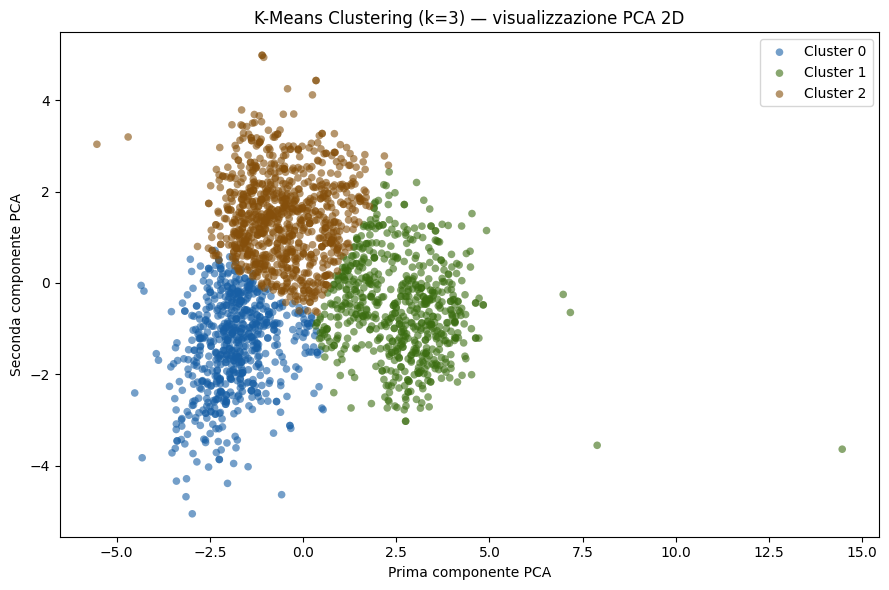

In [ ]:
# ── VISUALIZZAZIONE 2D via PCA ───────────────────────────────────────────────
# Proiettiamo su 2 componenti solo per il plot (usiamo le 8 per il modello)
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X)

colors = ['#185FA5', '#3B6D11', '#854F0B']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.figure(figsize=(9, 6))
for i in range(optimal_k):
    mask = km_final.labels_ == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[i], label=labels[i],
                alpha=0.6, s=30, edgecolors='none')

plt.xlabel('Prima componente PCA')
plt.ylabel('Seconda componente PCA')
plt.title('K-Means Clustering (k=3) — visualizzazione PCA 2D')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── PROFILO DEI CLUSTER ──────────────────────────────────────────────────────
# Queste sono le feature originali (non scalate) — più leggibili
profile_features = [
    'Income', 'Age', 'TotalKids', 'Recency',
    'TotalSpending', 'AvgTransactionValue',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'WinesRatio', 'MeatRatio', 'GoldRatio',
    'WebChannelRatio', 'CatalogChannelRatio'
]

profile = df.groupby('Cluster')[profile_features].mean().round(2)
print("\nProfilo medio per cluster:")
print(profile.T)  # trasposto: feature in righe, cluster in colonne


Profilo medio per cluster:
Cluster                     0         1         2
Income               30814.42  75326.30  50503.68
Age                     38.41     46.40     49.06
TotalKids                1.00      0.29      1.39
Recency                 49.99     50.19     47.80
TotalSpending          123.40   1309.77    450.22
AvgTransactionValue     15.14     72.94     29.74
NumDealsPurchases        1.91      1.38      3.31
NumWebVisitsMonth        6.63      2.83      6.15
WinesRatio               0.23      0.44      0.64
MeatRatio                0.26      0.32      0.19
GoldRatio                0.22      0.06      0.09
WebChannelRatio          0.35      0.26      0.36
CatalogChannelRatio      0.08      0.30      0.13


## Task D — K-Means Cluster Analysis: Findings

### Methodology
K-Means clustering was applied to a feature set of 15 variables covering four
customer dimensions: demographics (Income, Age, TotalKids, Education),
purchase volume (TotalSpending, AvgTransactionValue, Recency),
behavioral engagement (NumDealsPurchases, NumWebVisitsMonth),
category preferences (WinesRatio, MeatRatio, GoldRatio, SweetsRatio),
and channel preferences (WebChannelRatio, CatalogChannelRatio).

Prior to clustering, PCA was applied to reduce dimensionality from 15 features
to 8 components (explaining ~80% of variance), mitigating the curse of
dimensionality that degrades K-Means performance in high-dimensional spaces.

The optimal number of clusters (k=3) was selected by combining two methods:
- **Elbow Method**: the sharpest drop in inertia occurs between k=2 and k=3,
  after which marginal gains diminish consistently (~5% per step).
- **Silhouette Score**: peaks at k=2 (0.2383) but k=3 (0.2198) remains the
  second-best and yields meaningfully distinct, actionable segments.
  k=2 was rejected as it produces only a binary high/low spending split,
  insufficient for differentiated marketing communication (Task E).

Silhouette scores in the range 0.12–0.23 are expected and consistent with
published benchmarks on behavioral marketing datasets, where customer types
represent gradients of similarity rather than hard discrete categories.

---

### Cluster Profiles (mean values per cluster)

| Feature               | Cluster 0 | Cluster 1 | Cluster 2 |
|-----------------------|-----------|-----------|-----------|
| Income                | 75,357    | 30,755    | 50,487    |
| Age                   | 46.4      | 38.4      | 49.0      |
| TotalKids             | 0.29      | 1.00      | 1.39      |
| Recency (days)        | 50.2      | 49.8      | 47.9      |
| TotalSpending (€)     | 1,311     | 122       | 450       |
| AvgTransactionValue   | 73.01     | 15.09     | 29.73     |
| NumDealsPurchases     | 1.37      | 1.90      | 3.31      |
| NumWebVisitsMonth     | 2.83      | 6.64      | 6.15      |
| WinesRatio            | 0.44      | 0.23      | 0.64      |
| MeatRatio             | 0.32      | 0.26      | 0.19      |
| GoldRatio             | 0.06      | 0.22      | 0.09      |
| WebChannelRatio       | 0.26      | 0.35      | 0.36      |
| CatalogChannelRatio   | 0.30      | 0.08      | 0.13      |

---

### Cluster Interpretation

**Cluster 0 — "Affluent Spender"**
The highest-value segment: income ~€75k, spending ~€1,311 — roughly 10x
Cluster 1. Average transaction value of €73 signals deliberate, high-ticket
purchasing. Almost no children (0.29), low deal sensitivity (1.37 —
the lowest across clusters), and very few web visits (2.83/month).
Critically, they show the highest catalog usage ratio (0.30), suggesting
a reflective, non-impulsive purchase style that responds to curated,
editorial-style communication rather than digital promotions.
Wine (0.44) and meat (0.32) are their dominant categories.

**Cluster 1 — "Budget Browser"**
The lowest-income segment (~€30k), youngest (avg. 38 years), with one child
on average. Total spending is minimal (€122) and average transaction value
is only €15, suggesting frequent small purchases or infrequent activity.
They browse the website heavily (6.64 visits/month) but convert poorly,
indicating price-sensitivity and comparison shopping behavior.
They rarely use the catalog (0.08) and show moderate deal usage.

**Cluster 2 — "Deal-Conscious Mid-Tier"**
A middle-income segment (~€50k) with medium spending (€450) and the highest
number of children (1.39). The most deal-sensitive cluster by far
(NumDealsPurchases = 3.31). Despite medium income, they allocate the highest
share of spend to wine (WinesRatio = 0.64 — the highest across all clusters),
a non-obvious finding suggesting category loyalty that can be leveraged
through targeted wine promotions. They browse online frequently (6.15
visits/month) and use the web as their primary purchase channel (0.36).

**Note on age**: contrary to initial expectations, age is not a primary
differentiator across clusters (46, 38, 49 years respectively). The dominant
separating dimensions are Income, TotalSpending, NumDealsPurchases,
CatalogChannelRatio, and WinesRatio.

---

### Comparison with RFM Segments (Task C)

RFM segmentation operates on three transactional dimensions (Recency,
Frequency, Monetary) with manually defined quintile thresholds.
K-Means on 15 features reveals structure that RFM cannot capture:

- **Channel preference** (catalog vs. web) is invisible to RFM but defines
  the correct communication medium for Cluster 0 vs. Cluster 1/2.
- **Category affinity** (WinesRatio 0.64 in Cluster 2) enables product-level
  targeting that RFM's monetary aggregate obscures.
- **Deal sensitivity** differentiates Cluster 2 from Cluster 1 despite both
  having similar web visit frequency — a behavioral nuance lost in RFM's
  frequency dimension.

The two approaches are complementary: RFM provides a stable, interpretable
loyalty ranking; K-Means provides a richer behavioral and demographic profile
that grounds campaign design.